In [1]:
!pip install kaggle scikit-learn imbalanced-learn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve


In [5]:
from PIL import Image
import cv2

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [8]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d ham10000_dataset

print("Dataset downloaded successfully!")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.19G/5.20G [01:15<00:00, 37.8MB/s]
100% 5.20G/5.20G [01:15<00:00, 73.6MB/s]
Dataset downloaded successfully!


In [9]:
df_metadata = pd.read_csv('ham10000_dataset/HAM10000_metadata.csv')

print("="*80)
print("DATASET INFORMATION")
print("="*80)
print(f"\nDataset Shape: {df_metadata.shape}")
print(f"Number of Images: {len(df_metadata)}")
print("\nFirst 5 rows:")
print(df_metadata.head())

print("\n" + "="*80)
print("COLUMN INFORMATION")
print("="*80)
print(df_metadata.info())

print("\n" + "="*80)
print("MISSING VALUES")
print("="*80)
print(df_metadata.isnull().sum())

print("\n" + "="*80)
print("CLASS DISTRIBUTION")
print("="*80)
print(df_metadata['dx'].value_counts())

DATASET INFORMATION

Dataset Shape: (10015, 7)
Number of Images: 10015

First 5 rows:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  objec

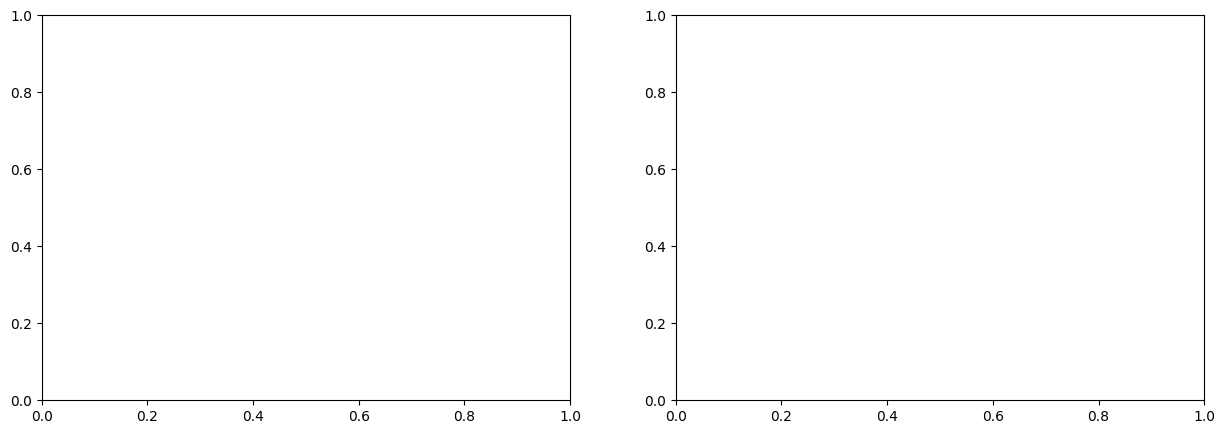

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

In [11]:
df_metadata['dx'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Skin Lesion Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lesion Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)


In [12]:
df_metadata['dx'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Percentage Distribution of Classes', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [13]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

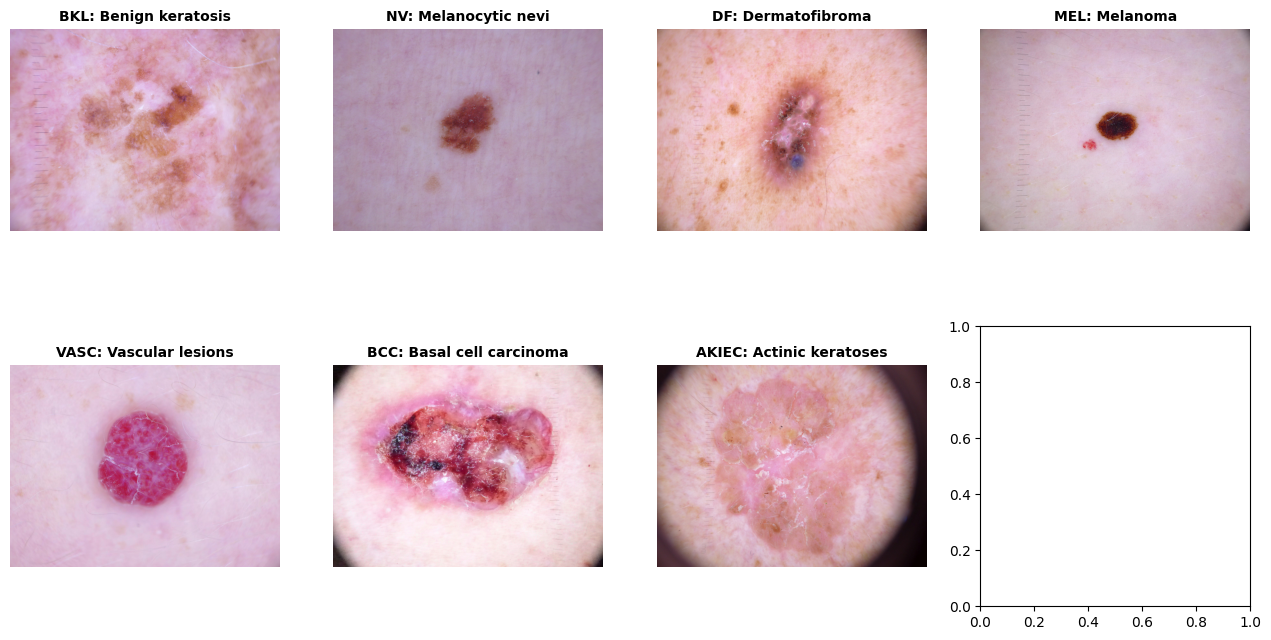

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, lesion_type in enumerate(df_metadata['dx'].unique()):
    sample_image_id = df_metadata[df_metadata['dx'] == lesion_type]['image_id'].iloc[0]

    # Try to load from either directory
    img_path1 = f'ham10000_dataset/HAM10000_images_part_1/{sample_image_id}.jpg'
    img_path2 = f'ham10000_dataset/HAM10000_images_part_2/{sample_image_id}.jpg'

    if os.path.exists(img_path1):
        img = Image.open(img_path1)
    else:
        img = Image.open(img_path2)

    axes[i].imshow(img)
    axes[i].set_title(f'{lesion_type.upper()}: {lesion_type_dict[lesion_type]}', fontsize=10, fontweight='bold')
    axes[i].axis('off')


In [15]:
axes[-1].axis('off')

plt.suptitle('Sample Images from Each Skin Lesion Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [16]:
print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)


DATA PREPROCESSING


In [17]:
IMG_SIZE = 224  # ResNet50 standard input size
BATCH_SIZE = 32
EPOCHS = 50

In [18]:
df_metadata['path'] = df_metadata['image_id'].apply(
    lambda x: os.path.join('ham10000_dataset/HAM10000_images_part_1', x + '.jpg')
    if os.path.exists(os.path.join('ham10000_dataset/HAM10000_images_part_1', x + '.jpg'))
    else os.path.join('ham10000_dataset/HAM10000_images_part_2', x + '.jpg')
)

In [19]:
df_metadata = df_metadata[df_metadata['path'].apply(os.path.exists)]
print(f"\nTotal valid images: {len(df_metadata)}")



Total valid images: 10015


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_metadata['label'] = le.fit_transform(df_metadata['dx'])

print("\nLabel Encoding:")
for i, class_name in enumerate(le.classes_):
    print(f"{i}: {class_name} ({lesion_type_dict[class_name]})")


Label Encoding:
0: akiec (Actinic keratoses)
1: bcc (Basal cell carcinoma)
2: bkl (Benign keratosis)
3: df (Dermatofibroma)
4: mel (Melanoma)
5: nv (Melanocytic nevi)
6: vasc (Vascular lesions)


In [21]:
X = df_metadata['path']
y = df_metadata['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")



Training samples: 8012
Testing samples: 2003


In [22]:
print("\n" + "="*80)
print("CREATING DATA GENERATORS")
print("="*80)


CREATING DATA GENERATORS


In [23]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


In [24]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [25]:
train_df = pd.DataFrame({
    'filename': X_train.values,
    'class': y_train.values.astype(str)
})

In [26]:
test_df = pd.DataFrame({
    'filename': X_test.values,
    'class': y_test.values.astype(str)
})

In [27]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 6410 validated image filenames belonging to 7 classes.


In [28]:
validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)


Found 1602 validated image filenames belonging to 7 classes.


In [29]:
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTraining batches: {len(train_generator)}")
print(f"Validation batches: {len(validation_generator)}")
print(f"Test batches: {len(test_generator)}")


Found 2003 validated image filenames belonging to 7 classes.

Training batches: 201
Validation batches: 51
Test batches: 63


In [30]:
print("\n" + "="*80)
print("BUILDING RESNET50 MODEL")
print("="*80)


BUILDING RESNET50 MODEL


In [31]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [32]:
base_model.trainable = False


In [33]:
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(7, activation='softmax')  # 7 classes
])

In [34]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
model.summary()

print(f"\nTotal parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Non-trainable parameters: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")



Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,137,159 (286.63 MB)

 Trainable params: 51,547,655 (196.64 MB)

 Non-trainable params: 23,589,504 (89.99 MB)


Total parameters: 75,137,159
Trainable parameters: 51,547,655
Non-trainable parameters: 23,589,504


In [35]:
print("\n" + "="*80)
print("SETTING UP CALLBACKS")
print("="*80)


SETTING UP CALLBACKS


In [36]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


In [37]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

In [38]:
checkpoint = ModelCheckpoint(
    'resnet50_best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, checkpoint]

print("Callbacks configured successfully!")

Callbacks configured successfully!


In [39]:
print("\n" + "="*80)
print("TRAINING RESNET50 MODEL")
print("="*80)

import time
start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time/60:.2f} minutes")


TRAINING RESNET50 MODEL
Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.4002 - loss: 1.9372
Epoch 1: val_accuracy improved from -inf to 0.72222, saving model to resnet50_best_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 201s 912ms/step - accuracy: 0.4008 - loss: 1.9353 - val_accuracy: 0.7222 - val_loss: 0.8598 - learning_rate: 0.0010
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.6777 - loss: 1.0323
Epoch 2: val_accuracy improved from 0.72222 to 0.73970, saving model to resnet50_best_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 149s 743ms/step - accuracy: 0.6778 - loss: 1.0321 - val_accuracy: 0.7397 - val_loss: 0.7471 - learning_rate: 0.0010
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.6998 - loss: 0.8846
Epoch 3: val_accuracy did not improve from 0.73970
201/201 ━━━━━━━━━━━━━━━━━━━━ 137s 684ms/step - accuracy: 0.6999 - loss: 0.8844 - val_accuracy: 0.7385 - val_loss: 0.7283 - learning_rate: 0.0010
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.7289 - loss: 0.7840
Epoch 4: val_accuracy improved from 0.73970 to 0.74844, saving model to resnet50_best_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 143s 711ms/step - accuracy: 0.7289 - loss: 0.7841 - val_accuracy: 0.7484 - val_loss: 0.6909 - learning_rate: 0.0010
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.7357 - loss: 0.7448
Epoch 5: val_accuracy improved from 0.74844 to 0.76717, saving model to resnet50_best_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 147s 733ms/step - accuracy: 0.7357 - loss: 0.7448 - val_accuracy: 0.7672 - val_loss: 0.6393 - learning_rate: 0.0010
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.7502 - loss: 0.7079
Epoch 6: val_accuracy did not improve from 0.76717
201/201 ━━━━━━━━━━━━━━━━━━━━ 136s 675ms/step - accuracy: 0.7502 - loss: 0.7079 - val_accuracy: 0.7628 - val_loss: 0.6319 - learning_rate: 0.0010
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.7471 - loss: 0.7001
Epoch 7: val_accuracy improved from 0.76717 to 0.77403, saving model to resnet50_best_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 141s 704ms/step - accuracy: 0.7471 - loss: 0.7001 - val_accuracy: 0.7740 - val_loss: 0.6065 - learning_rate: 0.0010
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.7602 - loss: 0.6665
Epoch 8: val_accuracy did not improve from 0.77403
201/201 ━━━━━━━━━━━━━━━━━━━━ 135s 674ms/step - accuracy: 0.7602 - loss: 0.6665 - val_accuracy: 0.7715 - val_loss: 0.6316 - learning_rate: 0.0010
Epoch 9/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.7626 - loss: 0.6593
Epoch 9: val_accuracy improved from 0.77403 to 0.78340, saving model to resnet50_best_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 147s 731ms/step - accuracy: 0.7626 - loss: 0.6593 - val_accuracy: 0.7834 - val_loss: 0.5954 - learning_rate: 0.0010
Epoch 10/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.7738 - loss: 0.6435
Epoch 10: val_accuracy did not improve from 0.78340
201/201 ━━━━━━━━━━━━━━━━━━━━ 136s 677ms/step - accuracy: 0.7738 - loss: 0.6435 - val_accuracy: 0.7821 - val_loss: 0.6051 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.

Training completed in 24.59 minutes


In [40]:
print("\n" + "="*80)
print("VISUALIZING TRAINING HISTORY")
print("="*80)


VISUALIZING TRAINING HISTORY


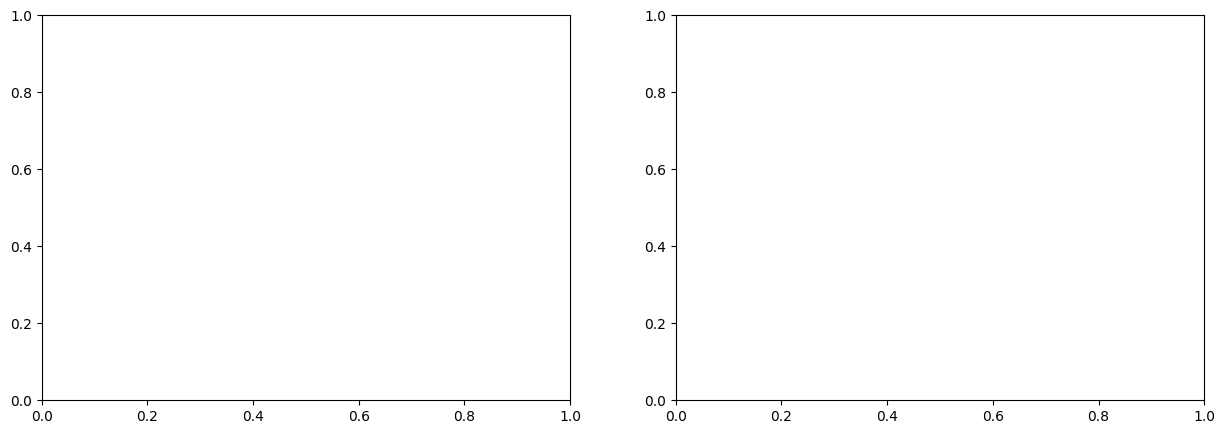

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


In [42]:
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('ResNet50 - Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)


In [43]:
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('ResNet50 - Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [44]:
print("\n" + "="*80)
print("MODEL EVALUATION ON TEST SET")
print("="*80)



MODEL EVALUATION ON TEST SET


In [45]:
model = keras.models.load_model('resnet50_best_model.h5')

In [46]:
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 378ms/step - accuracy: 0.7717 - loss: 0.6318

Test Loss: 0.6091
Test Accuracy: 0.7798 (77.98%)


In [47]:
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes


63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 294ms/step


In [48]:
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)



CLASSIFICATION REPORT


In [49]:
class_names = [lesion_type_dict[lesion] for lesion in le.classes_]

In [50]:
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    digits=4
)
print("\n" + report)


                      precision    recall  f1-score   support

   Actinic keratoses     0.5610    0.3538    0.4340        65
Basal cell carcinoma     0.5680    0.6893    0.6228       103
    Benign keratosis     0.6322    0.5000    0.5584       220
      Dermatofibroma     1.0000    0.0435    0.0833        23
            Melanoma     0.4475    0.7265    0.5538       223
    Melanocytic nevi     0.9269    0.8792    0.9024      1341
    Vascular lesions     0.5714    0.5714    0.5714        28

            accuracy                         0.7798      2003
           macro avg     0.6724    0.5377    0.5323      2003
        weighted avg     0.8067    0.7798    0.7822      2003



In [51]:
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")


Weighted Precision: 0.8067
Weighted Recall: 0.7798
Weighted F1-Score: 0.7822


In [52]:
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)



CONFUSION MATRIX


In [53]:
cm = confusion_matrix(y_true, y_pred_classes)

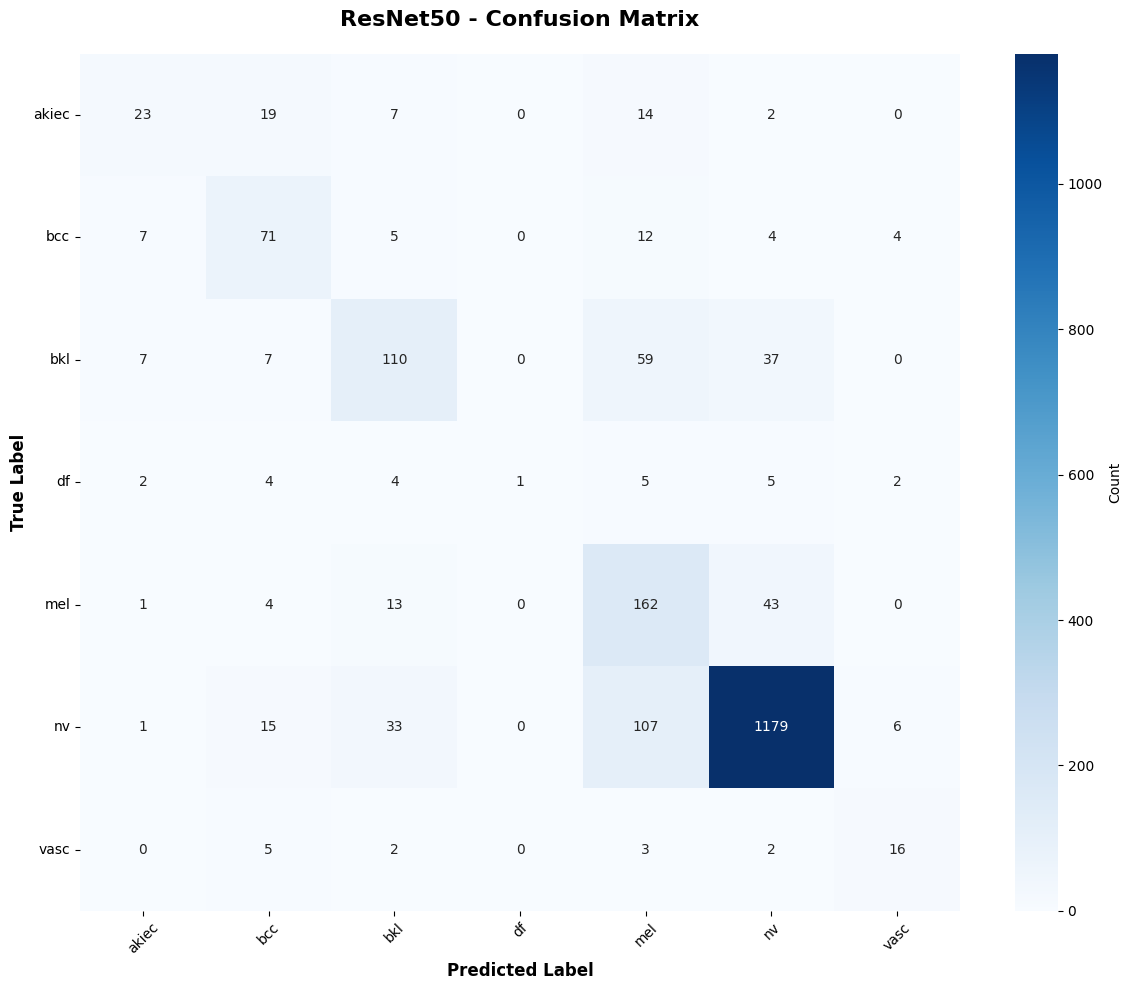

In [54]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar_kws={'label': 'Count'}
)
plt.title('ResNet50 - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

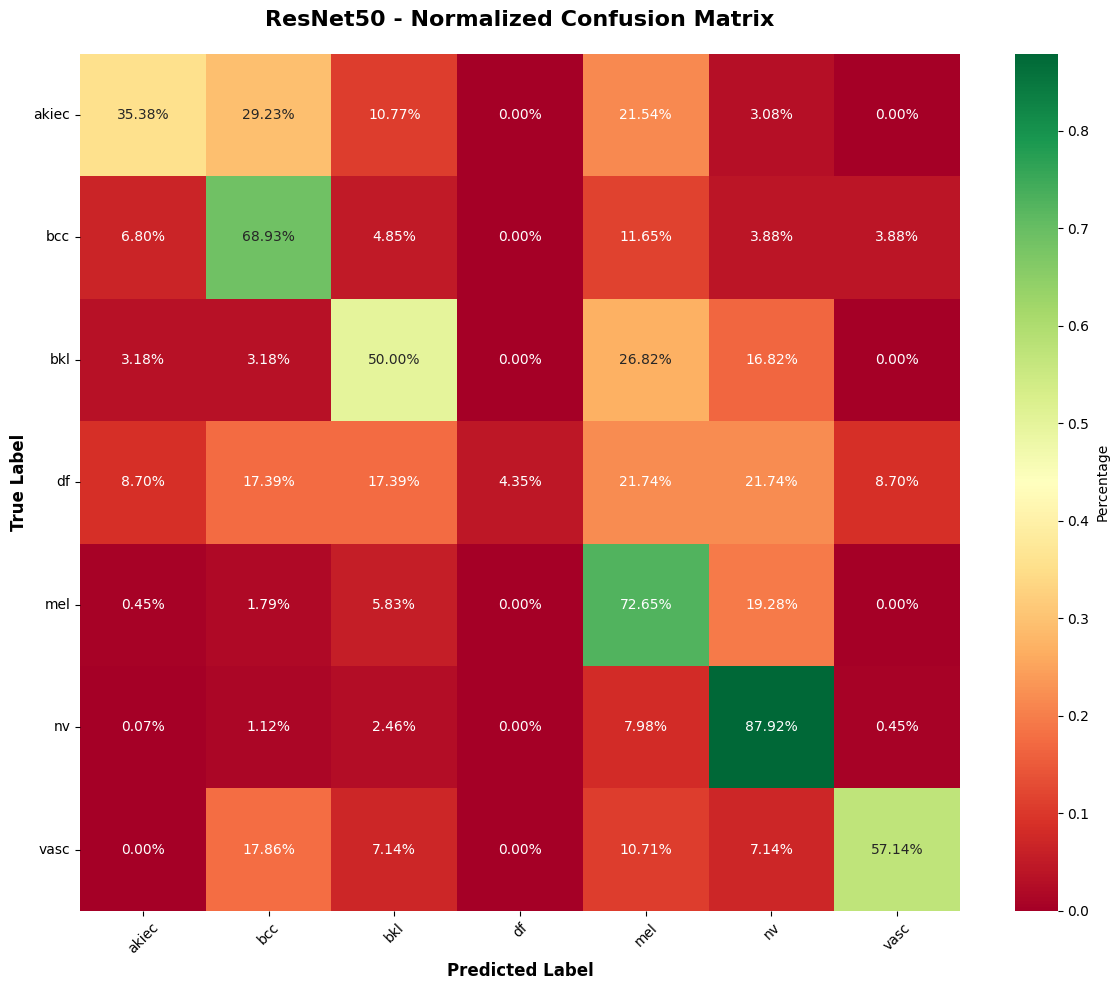

In [55]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='RdYlGn',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar_kws={'label': 'Percentage'}
)
plt.title('ResNet50 - Normalized Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
print("\n" + "="*80)
print("ROC-AUC ANALYSIS")
print("="*80)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle



ROC-AUC ANALYSIS


In [57]:
y_true_binary = label_binarize(y_true, classes=range(7))
n_classes = y_true_binary.shape[1]


In [58]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


In [59]:
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binary.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


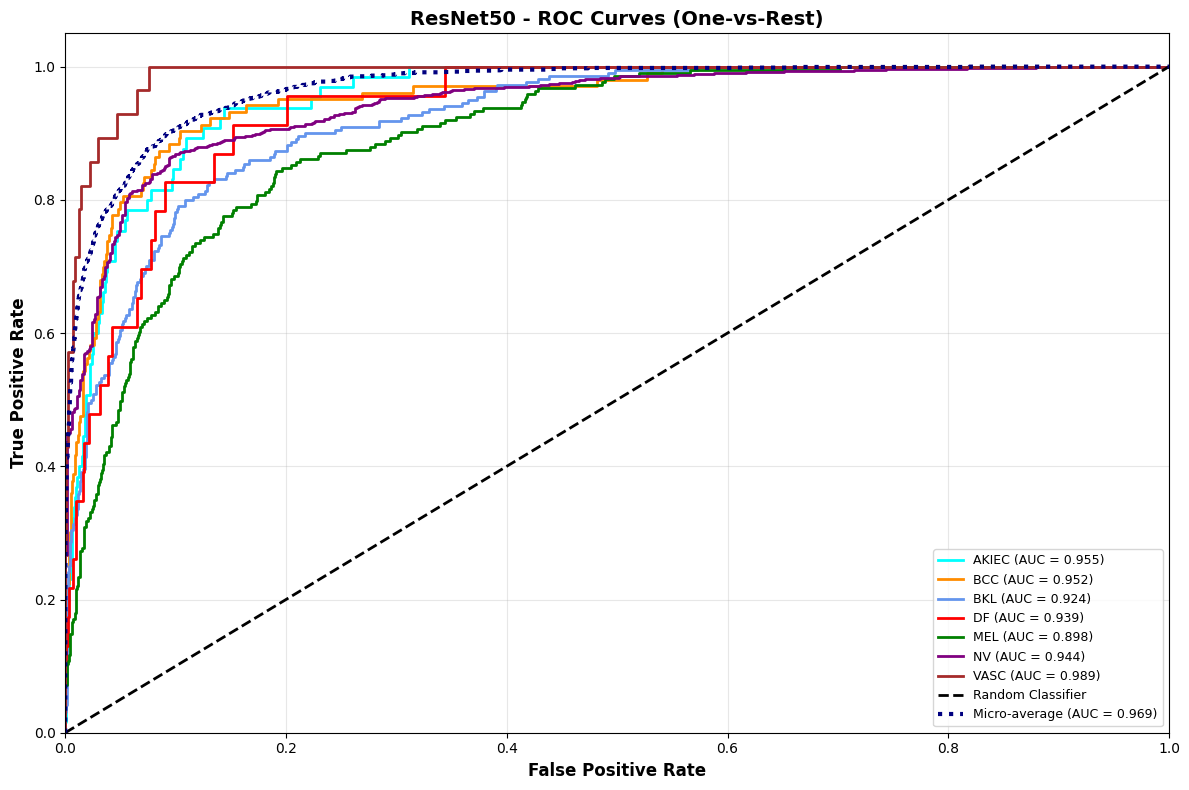


Micro-average AUC: 0.9689

Per-class AUC scores:
AKIEC: 0.9545
BCC: 0.9520
BKL: 0.9236
DF: 0.9386
MEL: 0.8981
NV: 0.9444
VASC: 0.9886


In [60]:
plt.figure(figsize=(12, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i], tpr[i],
        color=color,
        lw=2,
        label=f'{le.classes_[i].upper()} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.plot(fpr["micro"], tpr["micro"],
         color='navy', linestyle=':', linewidth=3,
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ResNet50 - ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMicro-average AUC: {roc_auc['micro']:.4f}")
print("\nPer-class AUC scores:")
for i in range(n_classes):
    print(f"{le.classes_[i].upper()}: {roc_auc[i]:.4f}")


In [61]:
print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80)


SAMPLE PREDICTIONS


In [62]:
test_generator.reset()
x_batch, y_batch = next(test_generator)


In [63]:
predictions = model.predict(x_batch)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_batch, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


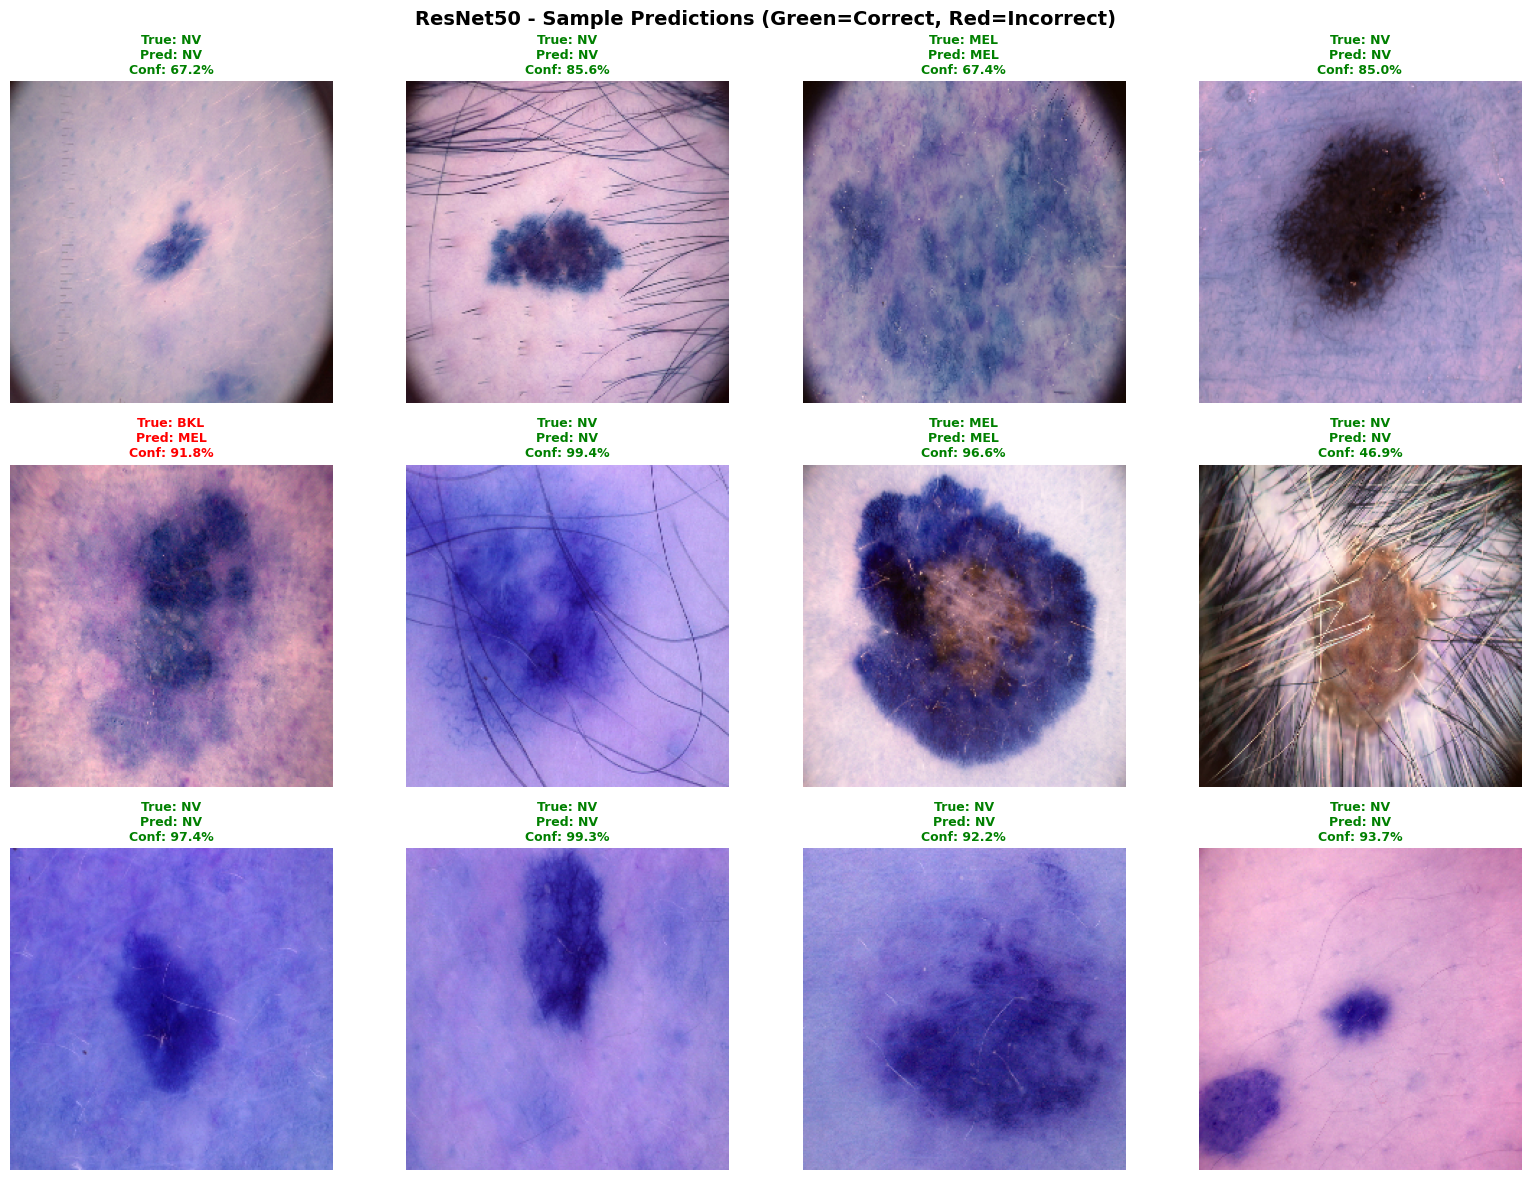

In [64]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i in range(12):
    if i < len(x_batch):
        # Denormalize image for display
        img = x_batch[i]
        img = (img - img.min()) / (img.max() - img.min())

        axes[i].imshow(img)

        true_label = le.classes_[true_classes[i]].upper()
        pred_label = le.classes_[predicted_classes[i]].upper()
        confidence = predictions[i][predicted_classes[i]] * 100

        color = 'green' if true_classes[i] == predicted_classes[i] else 'red'

        axes[i].set_title(
            f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%',
            fontsize=9,
            color=color,
            fontweight='bold'
        )
        axes[i].axis('off')

plt.suptitle('ResNet50 - Sample Predictions (Green=Correct, Red=Incorrect)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [65]:
print("\n" + "="*80)
print("RESNET50 MODEL - PERFORMANCE SUMMARY")
print("="*80)

summary_data = {
    'Metric': ['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC (Micro-avg)', 'Training Time'],
    'Value': [
        f'{test_accuracy*100:.2f}%',
        f'{precision:.4f}',
        f'{recall:.4f}',
        f'{f1:.4f}',
        f'{roc_auc["micro"]:.4f}',
        f'{training_time/60:.2f} minutes'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

print("\n" + "="*80)
print("MODEL SAVED SUCCESSFULLY!")
print("="*80)
print("Model file: resnet50_best_model.h5")



RESNET50 MODEL - PERFORMANCE SUMMARY

          Metric         Value
  Test Accuracy        77.98%
      Precision        0.8067
         Recall        0.7798
       F1-Score        0.7822
AUC (Micro-avg)        0.9689
  Training Time 24.59 minutes

MODEL SAVED SUCCESSFULLY!
Model file: resnet50_best_model.h5


In [67]:
confidence_scores = [y_pred_probs[i][y_pred_classes[i]] for i in range(len(y_pred_classes))]

results_df = pd.DataFrame({
    'True_Label': [le.classes_[i] for i in y_true],
    'Predicted_Label': [le.classes_[i] for i in y_pred_classes],
    'Confidence': confidence_scores,
    'Correct': [y_true[i] == y_pred_classes[i] for i in range(len(y_true))]
})

results_df.to_csv('resnet50_predictions.csv', index=False)
print("\nPredictions saved to: resnet50_predictions.csv")
print(f"Total predictions: {len(results_df)}")
print(f"Correct predictions: {results_df['Correct'].sum()}")
print(f"Incorrect predictions: {(~results_df['Correct']).sum()}")

# Show sample of results
print("\nSample predictions:")
print(results_df.head(10))

print("\n" + "="*80)
print("RESNET50 MODEL TRAINING AND EVALUATION COMPLETED!")
print("="*80)


Predictions saved to: resnet50_predictions.csv
Total predictions: 2003
Correct predictions: 1562
Incorrect predictions: 441

Sample predictions:
  True_Label Predicted_Label  Confidence  Correct
0         nv              nv    0.671615     True
1         nv              nv    0.855809     True
2        mel             mel    0.673553     True
3         nv              nv    0.849565     True
4        bkl             mel    0.917939    False
5         nv              nv    0.994464     True
6        mel             mel    0.965793     True
7         nv              nv    0.468711     True
8         nv              nv    0.973709     True
9         nv              nv    0.993398     True

RESNET50 MODEL TRAINING AND EVALUATION COMPLETED!
